## Exercise 2
### Exercise 02.1
Viene effettuata una stima tramite campionamento per calcolare l'integrale $I$:
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$
In primo luogo viene eseguito un campionamento con una distribuzione uniforme casuale nell'intervallo $[0,1]$, ottenendo il seguente grafico:
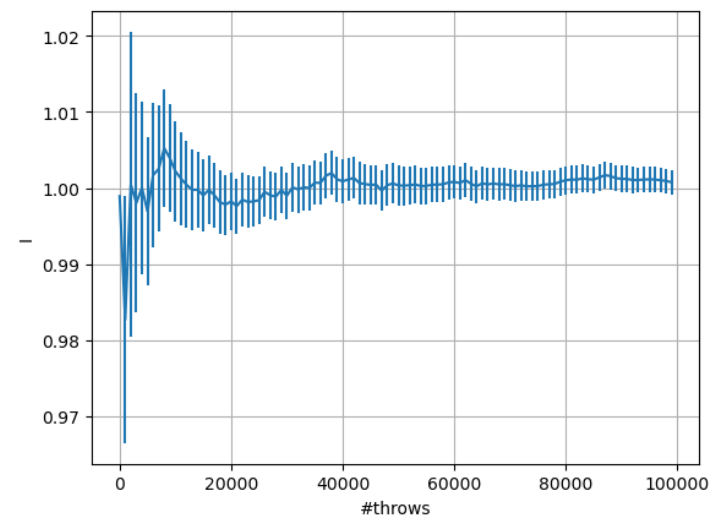

Si osserva che, all'aumentare del numero di blocchi, la stima converge progressivamente al valore atteso pari a $1$ e le fluttuazioni si riducono.

Successivamente viene applicata la tecnica dell'importance sampling. Come funzione di probabilità $d(x)$ si sceglie una funzione con una forma simile a quella dell'integranda $f(x)$, cioè che assuma valori maggiori in prossimità di $0$ (dove $f(x)$ è massima) e minori vicino a $x=1$. Partendo dalla funzione lineare decrescente $1-x$, questa viene normalizzata ottenendo:
$$d(x) = 2(1-x)$$
e quindi il seguente grafico:

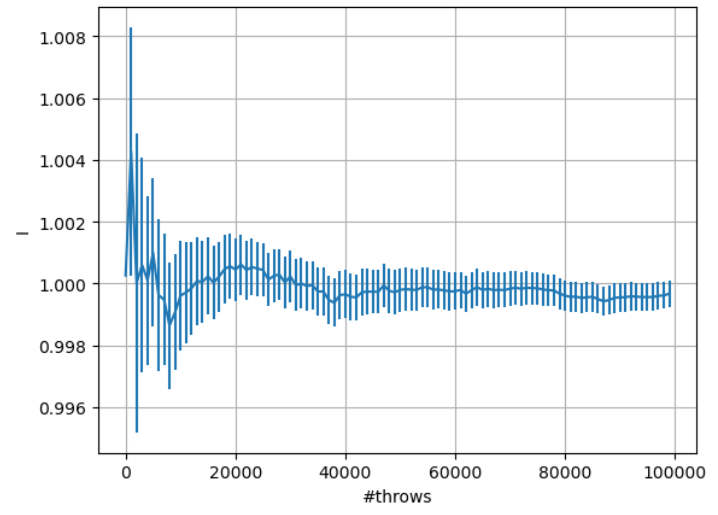

Come nel caso del campionamento uniforme, la stima converge a $I=1$, ma in modo molto più preciso: le barre d'errore sono più piccole ($0.001$ invece di $0.01$) e la curva risulta più stabile, grazie alla maggiore concentrazione dei punti nella regione in cui $f(x)$ fornisce il contributo principale.


In [ ]:
# Sampling a uniform distribution
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
    
def error(ave,ave2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((ave2[n] - ave[n]**2)/n)

def f(x):  # Function to calculate I
    return math.pi/2*math.cos(math.pi*x/2)

M=100000              # Total number of throws
N=100                 # Number of blocks
L=int(M/N)            # Number of throws in each block
np.random.seed(1)     # Fixing random seed for reproducibility
r = np.random.rand(M) # U[0,1) uniform distribution
x = np.arange(N)      # [0,1,2,...,N-1]
ave = np.zeros(N)
av2 = np.zeros(N)
sum_prog = np.zeros(N)
su2_prog = np.zeros(N)
err_prog = np.zeros(N)

b = 1     
a = 0

for i in range(N):
    sum1 = 0
    for j in range(L):
        k = j+i*L
        sum1 += f(r[k])
    ave[i] = (b-a)*sum1/L     # r_i 
    av2[i] = (ave[i])**2      # (r_i)^2 

for i in range(N):
    for j in range(i+1):
        sum_prog[i] += ave[j] # SUM_{j=0,i} r_j
        su2_prog[i] += av2[j] # SUM_{j=0,i} (r_j)^2
    sum_prog[i]/=(i+1) # Cumulative average
    su2_prog[i]/=(i+1) # Cumulative square average
    err_prog[i] = error(sum_prog,su2_prog,i) # Statistical uncertainty

x*=L # Number of throws = block * (Number of throws in each block)
plt.errorbar(x,sum_prog,yerr=err_prog)
plt.xlabel('#throws')
plt.ylabel('I')
plt.grid(True)
plt.show()

In [ ]:
# Importance sampling
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
    
def error(ave,ave2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((ave2[n] - ave[n]**2)/n)

def f(x):  # Function to calculate I
    return math.pi/2*math.cos(math.pi*x/2)

def d(x):  # Probability function
    return 2*(1-x)

M=100000                            # Total number of throws
N=100                               # Number of blocks
L=int(M/N)                          # Number of throws in each block
np.random.seed(1)                   # Fixing random seed for reproducibility
r = 1- np.sqrt(1-np.random.rand(M)) # U[0,1) uniform distribution
x = np.arange(N)                    # [0,1,2,...,N-1]
ave = np.zeros(N)
av2 = np.zeros(N)
sum_prog = np.zeros(N)
su2_prog = np.zeros(N)
err_prog = np.zeros(N)

b = 1     
a = 0

for i in range(N):
    sum1 = 0
    for j in range(L):
        k = j+i*L
        sum1 += f(r[k])/d(r[k])
    ave[i] = (b-a)*sum1/L     # r_i 
    av2[i] = (ave[i])**2      # (r_i)^2 

for i in range(N):
    for j in range(i+1):
        sum_prog[i] += ave[j] # SUM_{j=0,i} r_j
        su2_prog[i] += av2[j] # SUM_{j=0,i} (r_j)^2
    sum_prog[i]/=(i+1) # Cumulative average
    su2_prog[i]/=(i+1) # Cumulative square average
    err_prog[i] = error(sum_prog,su2_prog,i) # Statistical uncertainty

x*=L # Number of throws = block * (Number of throws in each block)
plt.errorbar(x,sum_prog,yerr=err_prog)
plt.xlabel('#throws')
plt.ylabel('I')
plt.grid(True)
plt.show()

### Exercise 02.2
Nella prima parte è stata eseguita la simulazione di una Random Walk tridimensionale $(x,y,z)$ su un reticolo cubico di $i=100$ passi, per ottenere il valore medio della distanza quadratica media dall'origine, $\sqrt{\langle |\vec{r}N|^2 \rangle{RW}}$. Si ottiene così il seguente grafico:

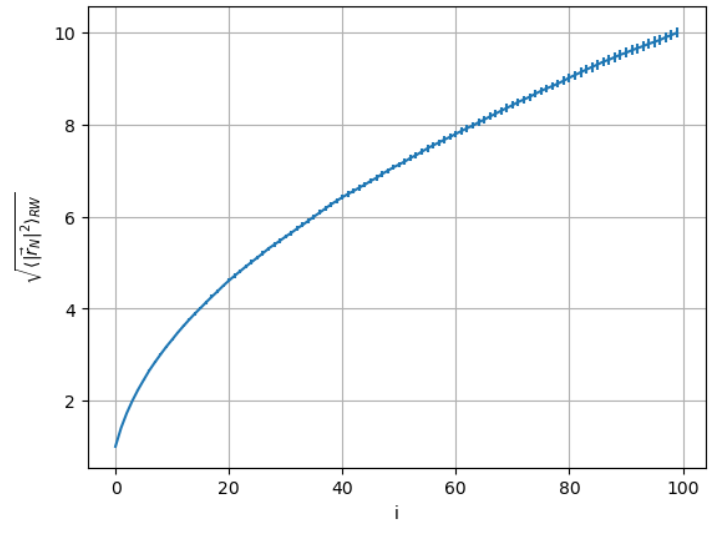

Il grafico mostra che la distanza cresce con il numero di passi $N$ secondo una legge proporzionale a $\sqrt{N}$, come previsto ($f(N)=k\sqrt{N}$). Ciò conferma il comportamento diffusivo caratteristico della Random Walk, in cui la distanza media aumenta con il tempo.

Nella seconda parte dell'esercizio viene analizzata una Random Walk *continua*, con $\theta \in [0,\pi]$ e $\phi \in [0,2\pi]$ distribuiti uniformemente (direzione casuale). L'angolo $\theta$ viene generato a partire da un coseno casuale per evitare un accumulo artificiale di punti ai poli. Applicando lo stesso procedimento si ottiene il seguente grafico:

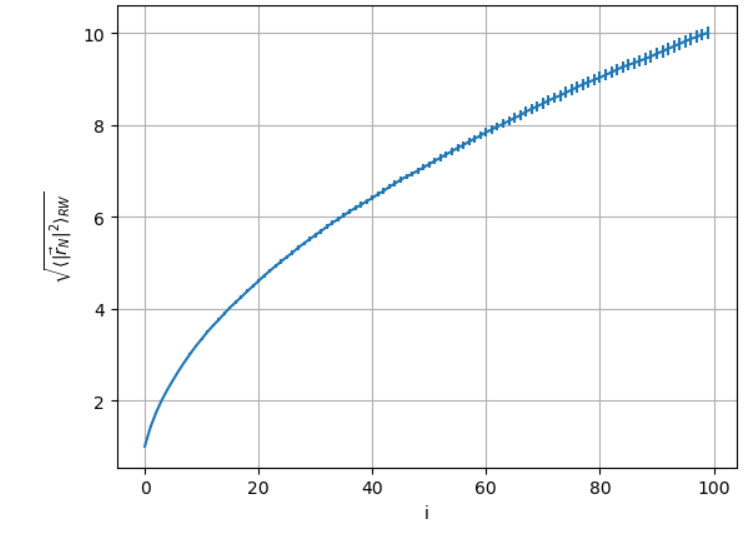

Il risultato mostra nuovamente la stessa legge proporzionale a $\sqrt{N}$ osservata nel caso precedente, confermando quanto analizzato in precedenza.

In [ ]:
# Discrete time
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
    
def error(ave,ave2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((ave2[n] - ave[n]**2)/n)

M=10000               # Total number of throws
N=100                 # Number of blocks
L=int(M/N)            # Number of throws in each block
steps=100             # Steps per walk
a=1                   # Lattice constant
np.random.seed(1)     # Fixing random seed for reproducibility
x = np.arange(steps)      # [0,1,2,...,N-1]
ave = np.zeros((N, steps))
av2 = np.zeros((N, steps))
sum_prog = np.zeros((N, steps))
su2_prog = np.zeros((N, steps))
err_prog = np.zeros((N, steps))

for i in range(N):
    sum = np.zeros(steps)
    for j in range(L):
        r = np.zeros(3)
        r2 = np.zeros(steps)
        for s in range(steps):
            axis = np.random.randint(0,3)      # x = 0, y = 1, z = 2
            if(np.random.rand() < 0.5):
                step = a
            else:
                step = -a
            r[axis] += step
            r2[s] = np.sum(r**2)
        sum += r2 
    ave[i] = sum/L
    av2[i] = (ave[i])**2

for i in range(N):
    for j in range(i+1):
        sum_prog[i] += ave[j] # SUM_{j=0,i} r_j
        su2_prog[i] += av2[j] # SUM_{j=0,i} (r_j)^2
    sum_prog[i]/=(i+1) # Cumulative average
    su2_prog[i]/=(i+1) # Cumulative square average
    for s in range(steps):
        err_prog[i][s] = error(sum_prog[:,s],su2_prog[:,s],i) # Statistical uncertainty

sum_prog = np.sqrt(sum_prog)
err_prog /= (2*np.sqrt(sum_prog))

#x*=L # Number of throws = block * (Number of throws in each block)
plt.errorbar(x,sum_prog[-1,:],yerr=err_prog[-1,:])
plt.xlabel('i')
plt.ylabel('$\\sqrt{\langle |\\vec{r}_N|^2 \\rangle_{RW}}$')
plt.grid(True)
plt.show()

In [ ]:
# Continium walk
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
    
def error(ave,ave2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((ave2[n] - ave[n]**2)/n)

M=10000               # Total number of throws
N=100                 # Number of blocks
L=int(M/N)            # Number of throws in each block
steps=100             # Steps per walk
a=1                   # Lattice constant
np.random.seed(1)     # Fixing random seed for reproducibility
x = np.arange(steps)      # [0,1,2,...,N-1]
ave = np.zeros((N, steps))
av2 = np.zeros((N, steps))
sum_prog = np.zeros((N, steps))
su2_prog = np.zeros((N, steps))
err_prog = np.zeros((N, steps))

for i in range(N):
    sum = np.zeros(steps)
    for j in range(L):
        r = np.zeros(3)
        r2 = np.zeros(steps)
        
        for s in range(steps):
            cos_theta = np.random.uniform(-1, 1)          # uniform cos(theta)
            theta = math.acos(cos_theta)                  # uniform theta
            phi = np.random.uniform(0, 2*math.pi)         # uniform phi
            r += [a*math.sin(theta)*math.cos(phi), a*math.sin(theta)*math.sin(phi), a*math.cos(theta)]
            r2[s] = np.sum(r**2)                          # |r|^2
        sum += r2 
    ave[i] = sum/L
    av2[i] = (ave[i])**2

for i in range(N):
    for j in range(i+1):
        sum_prog[i] += ave[j] # SUM_{j=0,i} r_j
        su2_prog[i] += av2[j] # SUM_{j=0,i} (r_j)^2
    sum_prog[i]/=(i+1) # Cumulative average
    su2_prog[i]/=(i+1) # Cumulative square average
    for s in range(steps):
        err_prog[i][s] = error(sum_prog[:,s],su2_prog[:,s],i) # Statistical uncertainty

sum_prog = np.sqrt(sum_prog)
err_prog /= (2*np.sqrt(sum_prog))

#x*=L # Number of throws = block * (Number of throws in each block)
plt.errorbar(x,sum_prog[-1,:],yerr=err_prog[-1,:])
plt.xlabel('i')
plt.ylabel('$\\sqrt{\langle |\\vec{r}_N|^2 \\rangle_{RW}}$')
plt.grid(True)
plt.show()